# Phase 2 — Cascade Metrics

**Goal:** for each thread, compute metrics covering reach, speed, and structure. Then look at distributions by veracity to see which dimensions actually differ across rumour vs. non-rumour and within rumour types.

**Why this is the most important phase:** Phase 1 told us that on simple cascade size, **non-rumours are the largest cascades on PHEME** — the opposite of what most readers expect. The interesting question now is whether rumours and facts spread in *different shapes* even when their reach is comparable. Structural virality (Goel et al. 2016) is the key metric — it separates **broadcast** spread (one big account → many shallow replies) from **viral** spread (long peer-to-peer chains). If false rumours have lower reach but higher structural virality than non-rumours, that's a real and presentable finding.

**Outputs:**
- `data/processed/metrics.parquet` (or `.pkl`) — one row per thread with all metrics
- `data/processed/threads_with_metrics.parquet` — `threads_df` joined to metrics for convenience

---

## 1. Setup

In [1]:
#!pip install seaborn

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path('..').resolve() / 'src'))
from cascade_metrics import compute_all_metrics

DATA_DIR = Path('../data/processed')

sns.set_style('whitegrid')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

# Consistent veracity colors across the whole project — set them once here
# and reuse in Phase 4 figures so the presentation feels coherent.
VERACITY_ORDER = ['nonrumour', 'true', 'unverified', 'false']
VERACITY_COLORS = {
    'nonrumour':  '#4C72B0',  # blue
    'true':       '#55A868',  # green
    'unverified': '#DD8452',  # orange
    'false':      '#C44E52',  # red
}

## 2. Load Phase 1 outputs

In [3]:
# Load whichever format Phase 1 produced
def _load(name):
    pq, pkl = DATA_DIR / f'{name}.parquet', DATA_DIR / f'{name}.pkl'
    if pq.exists():
        return pd.read_parquet(pq)
    return pd.read_pickle(pkl)

threads_df = _load('threads')
tweets_df = _load('tweets')
edges_df = _load('edges')

print(f'threads: {len(threads_df):>6,}')
print(f'tweets:  {len(tweets_df):>6,}')
print(f'edges:   {len(edges_df):>6,}')

threads:  6,425
tweets:  105,354
edges:   95,076


## 3. Compute metrics

On full PHEME-9 (~6,400 threads) this takes ~1–3 minutes depending on machine. The expensive step is structural virality, which requires all-pairs shortest paths in each cascade tree — fine for trees with <500 nodes but slows down on the rare giant cascade.

If you need to iterate fast, set `SAMPLE = 200` for testing.

In [4]:
SAMPLE = None  # set to e.g. 200 for fast iteration; None for full run

if SAMPLE:
    threads_subset = threads_df.sample(n=SAMPLE, random_state=42)
    tweets_subset = tweets_df[tweets_df['thread_id'].isin(threads_subset['thread_id'])]
    edges_subset = edges_df[edges_df['thread_id'].isin(threads_subset['thread_id'])]
    print(f'Computing on {len(threads_subset)} threads (SAMPLE mode)')
else:
    threads_subset, tweets_subset, edges_subset = threads_df, tweets_df, edges_df
    print(f'Computing on all {len(threads_subset):,} threads')

metrics_df = compute_all_metrics(threads_subset, tweets_subset, edges_subset)
print(f'\nDone. Metrics shape: {metrics_df.shape}')
metrics_df.head()

Computing on all 6,425 threads
  ...   500/6425 threads
  ...  1000/6425 threads
  ...  1500/6425 threads
  ...  2000/6425 threads
  ...  2500/6425 threads
  ...  3000/6425 threads
  ...  3500/6425 threads
  ...  4000/6425 threads
  ...  4500/6425 threads
  ...  5000/6425 threads
  ...  5500/6425 threads
  ...  6000/6425 threads

Done. Metrics shape: (6425, 13)


,thread_id,cascade_size,max_depth,max_breadth,unique_users,time_to_first_reply_min,time_to_half_cascade_min,reply_velocity_first_hour,tweets_with_timestamps,structural_virality,wiener_index,broadcast_ratio,branching_factor_mean
0,552783238415265792,10,5,5,7,18.116667,39.400000,4,10,2.911111,131.0,0.555556,1.800000
1,552783667052167168,8,3,5,7,6.783333,21.800000,6,8,2.214286,62.0,0.714286,2.333333
2,552783745565347840,6,1,5,6,5.616667,9.733333,4,6,1.666667,25.0,1.000000,5.000000
3,552784168849907712,14,10,3,6,1.533333,24.366667,12,14,4.494505,409.0,0.230769,1.300000
4,552784526955806720,17,5,10,13,0.683333,8.983333,14,17,3.058824,416.0,0.625000,2.285714


## 4. Join metrics back to threads_df

In [5]:
tm = threads_subset.merge(metrics_df, on='thread_id', how='left')
print(f'Joined: {tm.shape}')
print(f'Columns: {list(tm.columns)}')

Joined: (6425, 32)
Columns: ['thread_id', 'event', 'is_rumour', 'veracity', 'rumour_description', 'is_turnaround', 'source_user_id', 'source_user_screen_name', 'source_user_followers', 'source_user_verified', 'source_created_at', 'source_text', 'source_retweet_count', 'source_favorite_count', 'n_reactions', 'n_edges', 'n_tweets_in_structure', 'n_skipped_malformed_nodes', 'tweets_we_have', 'structure_completeness', 'cascade_size', 'max_depth', 'max_breadth', 'unique_users', 'time_to_first_reply_min', 'time_to_half_cascade_min', 'reply_velocity_first_hour', 'tweets_with_timestamps', 'structural_virality', 'wiener_index', 'broadcast_ratio', 'branching_factor_mean']


## 5. Headline summaries by veracity

First look — does each metric differ across veracity classes? We'll show median (robust to heavy tails) and p90 (captures the tail behavior, where the action often is).

In [6]:
metric_cols = [
    'cascade_size', 'max_depth', 'max_breadth', 'unique_users',
    'time_to_first_reply_min', 'time_to_half_cascade_min', 'reply_velocity_first_hour',
    'structural_virality', 'wiener_index', 'broadcast_ratio', 'branching_factor_mean',
]

summary_median = tm.groupby('veracity')[metric_cols].median().round(2).reindex(VERACITY_ORDER)
summary_p90 = tm.groupby('veracity')[metric_cols].quantile(0.9).round(2).reindex(VERACITY_ORDER)

print('=== MEDIAN by veracity ===')
print(summary_median.T)
print()
print('=== P90 by veracity ===')
print(summary_p90.T)

=== MEDIAN by veracity ===
veracity                   nonrumour    true  unverified  false
cascade_size                   13.00   11.00       11.00   6.00
max_depth                       2.00    2.00        2.00   1.00
max_breadth                     8.00    8.00        8.00   4.00
unique_users                   11.00    9.00       10.00   5.00
time_to_first_reply_min         1.77    1.56        0.93   2.18
time_to_half_cascade_min       20.80   10.29       12.08  11.25
reply_velocity_first_hour       7.00    8.00        7.00   4.00
structural_virality             2.13    1.98        2.09   1.96
wiener_index                  180.00  121.00      126.00  35.00
broadcast_ratio                 0.82    0.88        0.83   0.86
branching_factor_mean           3.17    3.50        3.33   2.79

=== P90 by veracity ===
veracity                   nonrumour     true  unverified   false
cascade_size                   34.00    25.00       31.30   22.00
max_depth                       8.00     6.00   

**How to read these tables.** Each column is a veracity class. Each row is a metric. Look across each row: is one class consistently higher or lower than the others? In particular:

- **Reach metrics** (cascade_size, max_depth, max_breadth, unique_users): Phase 1 already told us non-rumours dominate on cascade_size. Do they also dominate on depth and breadth, or is the dominance reach-only?
- **Speed metrics** (time_to_first_reply, time_to_half_cascade, reply_velocity_first_hour): are rumours faster than non-rumours? *This* is where the Vosoughi-style finding might live, even if total reach goes the other way.
- **Structure metrics** (structural_virality, broadcast_ratio): if non-rumours have low structural virality and high broadcast ratio, while rumours have higher virality, that's the punchline figure of the presentation. It would mean: *non-rumours reach more people via broadcast (BBC-tweet → many replies), but rumours spread more virally (peer-to-peer chains).*

## 6. Distribution plots — log scale, by veracity

Medians can hide everything. These plots are sanity checks, not final figures — Phase 4 will polish whatever turns out to be the real story. The goal here is just to see *what* the distributions look like.

/var/folders/d3/6grffqks28g_kc1bfbd4ycbr0000gn/T/ipykernel_27121/2669913756.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/d3/6grffqks28g_kc1bfbd4ycbr0000gn/T/ipykernel_27121/2669913756.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/d3/6grffqks28g_kc1bfbd4ycbr0000gn/T/ipykernel_27121/2669913756.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/d3/6grffqks28g_kc1bfbd4ycbr0000gn/T/ipykernel_27121/2669913756.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

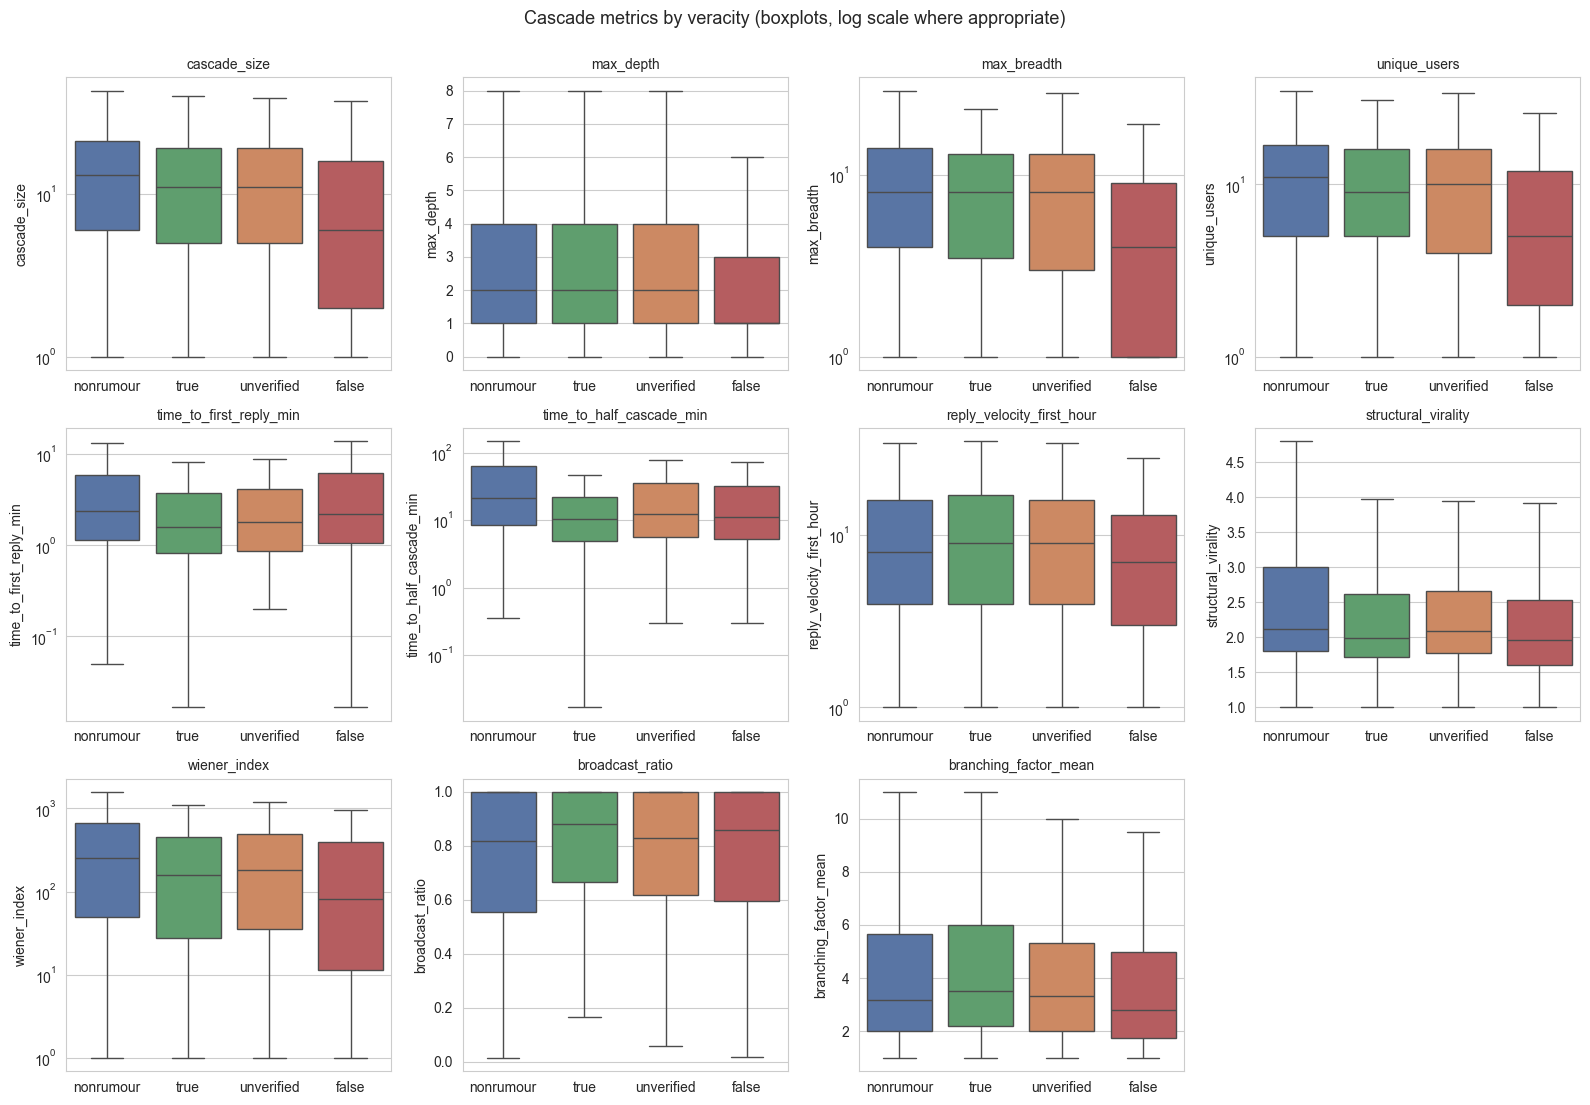

In [7]:
def plot_metric_by_veracity(df, col, log=True, ax=None):
    """Box plot with consistent ordering and colors."""
    data = df[df[col].notna() & (df[col] > 0 if log else True)]
    ax = ax or plt.gca()
    sns.boxplot(
        data=data, x='veracity', y=col,
        order=VERACITY_ORDER,
        palette=[VERACITY_COLORS[v] for v in VERACITY_ORDER],
        showfliers=False,  # outliers obscure the box; mention max separately
        ax=ax,
    )
    if log:
        ax.set_yscale('log')
    ax.set_xlabel('')
    ax.set_title(col, fontsize=10)
    return ax

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

log_metrics = {'cascade_size', 'max_breadth', 'unique_users', 'wiener_index',
               'time_to_first_reply_min', 'time_to_half_cascade_min',
               'reply_velocity_first_hour'}

for ax, col in zip(axes, metric_cols):
    plot_metric_by_veracity(tm, col, log=(col in log_metrics), ax=ax)

# Hide unused subplot
for ax in axes[len(metric_cols):]:
    ax.axis('off')

plt.suptitle('Cascade metrics by veracity (boxplots, log scale where appropriate)', y=1.00, fontsize=13)
plt.tight_layout()
plt.savefig('../rumors/figures/phase2_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Per-event check — does the pattern hold within events?

Pooled stats can be misleading when events differ massively in size and composition. If unverified rumours look big in pooled data but it's all driven by Ferguson, that's important to know.

In [8]:
# Per-event median for the most important metrics
key_metrics = ['cascade_size', 'max_depth', 'structural_virality', 'broadcast_ratio',
               'time_to_first_reply_min']

for metric in key_metrics:
    print(f'\n=== Median {metric} by event × veracity ===')
    pivot = (
        tm.groupby(['event', 'veracity'])[metric]
        .median()
        .unstack('veracity')
        .reindex(columns=VERACITY_ORDER)
        .round(2)
    )
    print(pivot)


=== Median cascade_size by event × veracity ===
veracity           nonrumour  true  unverified  false
event                                                
charliehebdo            16.0  12.0        13.0    9.5
ebola-essien             NaN   NaN         NaN   15.5
ferguson                14.0  17.0        16.5   12.5
germanwings-crash        5.5   5.0         9.5    5.0
gurlitt                  1.0   1.0         1.0    NaN
ottawashooting          11.0  12.0        11.0    9.0
prince-toronto           1.5   NaN         3.0    2.0
putinmissing             2.0   NaN         2.0    1.0
sydneysiege             18.0  15.0        13.5   18.0

=== Median max_depth by event × veracity ===
veracity           nonrumour  true  unverified  false
event                                                
charliehebdo             2.0   2.0         2.0    2.0
ebola-essien             NaN   NaN         NaN    3.0
ferguson                 2.0   3.0         3.0    4.5
germanwings-crash        1.0   1.0       

## 8. Save outputs

These feed directly into Phase 3 (statistical tests + within-event comparisons).

In [9]:
try:
    metrics_df.to_parquet(DATA_DIR / 'metrics.parquet', index=False)
    tm.to_parquet(DATA_DIR / 'threads_with_metrics.parquet', index=False)
    ext = 'parquet'
except ImportError:
    metrics_df.to_pickle(DATA_DIR / 'metrics.pkl')
    tm.to_pickle(DATA_DIR / 'threads_with_metrics.pkl')
    ext = 'pkl'

print(f'Saved as .{ext}:')
for p in sorted(DATA_DIR.glob(f'*.{ext}')):
    print(f'  {p.name}  ({p.stat().st_size/1024:.1f} KB)')

Saved as .parquet:
  edges.parquet  (1966.4 KB)
  metrics.parquet  (226.1 KB)
  threads.parquet  (754.6 KB)
  threads_with_metrics.parquet  (888.6 KB)
  tweets.parquet  (12059.3 KB)


In [10]:
ferg = tweets_df[tweets_df['thread_id'].isin(
    threads_df[threads_df['event']=='ferguson']['thread_id']
)]
print("Unique ferguson timestamp seconds (first 20):")
print(ferg['created_at'].dt.second.value_counts().head(20))
print()
print("Time deltas in ferguson (raw, first 20):")
ferg_threads = threads_df[threads_df['event']=='ferguson'].head(5)
for _, t in ferg_threads.iterrows():
    src_time = t['source_created_at']
    replies = ferg[(ferg['thread_id']==t['thread_id']) & (~ferg['is_source'])]
    if len(replies):
        print(f"  thread {t['thread_id']}: src={src_time}, first reply={replies['created_at'].min()}")

Unique ferguson timestamp seconds (first 20):
created_at
57    465
34    453
44    438
10    438
49    433
54    432
26    427
2     427
46    424
41    423
30    422
47    419
12    419
0     417
33    417
13    416
7     414
24    413
20    411
55    411
Name: count, dtype: int64

Time deltas in ferguson (raw, first 20):
  thread 498254340310966273: src=2014-08-09 23:47:46+00:00, first reply=2014-08-09 23:47:46+00:00
  thread 498254929942028288: src=2014-08-09 23:50:07+00:00, first reply=2014-08-09 23:50:07+00:00
  thread 498272309535191041: src=2014-08-10 00:59:10+00:00, first reply=2014-08-10 00:59:10+00:00
  thread 498280126254428160: src=2014-08-10 01:30:14+00:00, first reply=2014-08-10 01:30:14+00:00
  thread 498293668655423488: src=2014-08-10 02:24:03+00:00, first reply=2014-08-10 02:24:03+00:00


In [11]:
for event in threads_df['event'].unique():
    event_threads = threads_df[threads_df['event']==event].head(20)
    n_self_replies = 0
    n_total_with_replies = 0
    for _, t in event_threads.iterrows():
        replies = tweets_df[
            (tweets_df['thread_id']==t['thread_id']) & 
            (~tweets_df['is_source'])
        ].sort_values('created_at')
        if len(replies) == 0:
            continue
        n_total_with_replies += 1
        first_reply_id = replies.iloc[0]['tweet_id']
        if first_reply_id == t['thread_id']:
            n_self_replies += 1
    print(f'{event:25s} {n_self_replies}/{n_total_with_replies} threads have source duplicated in reactions/')

charliehebdo              0/20 threads have source duplicated in reactions/
ebola-essien              0/14 threads have source duplicated in reactions/
ferguson                  15/17 threads have source duplicated in reactions/
germanwings-crash         0/20 threads have source duplicated in reactions/
gurlitt                   0/4 threads have source duplicated in reactions/
ottawashooting            0/20 threads have source duplicated in reactions/
prince-toronto            0/14 threads have source duplicated in reactions/
putinmissing              0/16 threads have source duplicated in reactions/
sydneysiege               0/20 threads have source duplicated in reactions/


---

## What to check before moving to Phase 3

Look at the median table in section 5 and the per-event tables in section 7. Three questions to answer:

1. **Is structural_virality higher for rumours than non-rumours?** If yes, the presentation has a real story even though total reach goes the other way.
2. **Are rumours faster (lower time_to_first_reply) than non-rumours?** If yes, you have a Vosoughi-style speed finding, just with reduced overall reach.
3. **Does the pattern hold across events, or is it driven by 1-2 events?** If pooled and per-event give different answers, the per-event view wins for the presentation — show stratified results, not pooled ones.

Phase 3 will turn whichever of these patterns is real into proper statistical tests with effect sizes and confidence intervals.